In [1]:
import sys
if "ESP32_env" not in sys.executable:
    print("/n环境配置错误!!!/n")
    print(sys.executable)
else:
    print("环境配置正常")

环境配置正常


In [3]:
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt 
from matplotlib import rcParams # 字体配置,支持中文
rcParams['font.family'] = 'SimHei'
rcParams['axes.unicode_minus'] = False  # 解决负号不显示的问题

import tensorflow as tf
import math

In [ ]:
# ----------------- 1. 构建模拟数据 -----------------
np.random.seed(42)
N_LOW = 1000      # 低风险组: 1000组
N_MID = 250       # 中风险每个小区间: 5*250组
N_HIGH = 250      # 高风险每个小区间: 5*250组

# ----------------- 1-1. 低风险数据 -----------------
temp_low = np.random.uniform(20, 26, N_LOW)
humi_low = np.random.uniform(40, 60, N_LOW)
gray_low = np.random.uniform(0, 0.1, N_LOW)

# ----------------- 1-2. 中风险数据 -----------------
# 中风险5个子区间，每个250组
mid_data = []
# t:18-20, h&g:低风险区间
mid_data.append(np.column_stack((
    np.random.uniform(18, 20, N_MID),
    np.random.uniform(40, 60, N_MID),
    np.random.uniform(0, 0.1, N_MID)
)))
# t:26-28
mid_data.append(np.column_stack((
    np.random.uniform(26, 28, N_MID),
    np.random.uniform(40, 60, N_MID),
    np.random.uniform(0, 0.1, N_MID)
)))
# h:35-40
mid_data.append(np.column_stack((
    np.random.uniform(20, 26, N_MID),
    np.random.uniform(35, 40, N_MID),
    np.random.uniform(0, 0.1, N_MID)
)))
# h:60-65
mid_data.append(np.column_stack((
    np.random.uniform(20, 26, N_MID),
    np.random.uniform(60, 65, N_MID),
    np.random.uniform(0, 0.1, N_MID)
)))
# g:0.1-0.2
mid_data.append(np.column_stack((
    np.random.uniform(20, 26, N_MID),
    np.random.uniform(40, 60, N_MID),
    np.random.uniform(0.1, 0.2, N_MID)
)))
temp_mid = np.concatenate([x[:,0] for x in mid_data])
humi_mid = np.concatenate([x[:,1] for x in mid_data])
gray_mid = np.concatenate([x[:,2] for x in mid_data])

# ----------------- 1-3. 高风险数据 -----------------
# 高风险5个子区间，每个250组
high_data = []
# t<18
high_data.append(np.column_stack((
    np.random.uniform(10, 18, N_HIGH),
    np.random.uniform(40, 60, N_HIGH),
    np.random.uniform(0, 0.1, N_HIGH)
)))
# t>28
high_data.append(np.column_stack((
    np.random.uniform(28, 40, N_HIGH),
    np.random.uniform(40, 60, N_HIGH),
    np.random.uniform(0, 0.1, N_HIGH)
)))
# h<35
high_data.append(np.column_stack((
    np.random.uniform(20, 26, N_HIGH),
    np.random.uniform(20, 35, N_HIGH),
    np.random.uniform(0, 0.1, N_HIGH)
)))
# h>65
high_data.append(np.column_stack((
    np.random.uniform(20, 26, N_HIGH),
    np.random.uniform(65, 90, N_HIGH),
    np.random.uniform(0, 0.1, N_HIGH)
)))
# g>0.2
high_data.append(np.column_stack((
    np.random.uniform(20, 26, N_HIGH),
    np.random.uniform(40, 60, N_HIGH),
    np.random.uniform(0.2, 1.0, N_HIGH)
)))
temp_high = np.concatenate([x[:,0] for x in high_data])
humi_high = np.concatenate([x[:,1] for x in high_data])
gray_high = np.concatenate([x[:,2] for x in high_data])

# ----------------- 1-4. 拼接所有数据 -----------------
temp = np.concatenate([temp_low, temp_mid, temp_high])
humi = np.concatenate([humi_low, humi_mid, humi_high])
gray = np.concatenate([gray_low, gray_mid, gray_high])

risk
1    1250
2    1250
0    1000
Name: count, dtype: int64


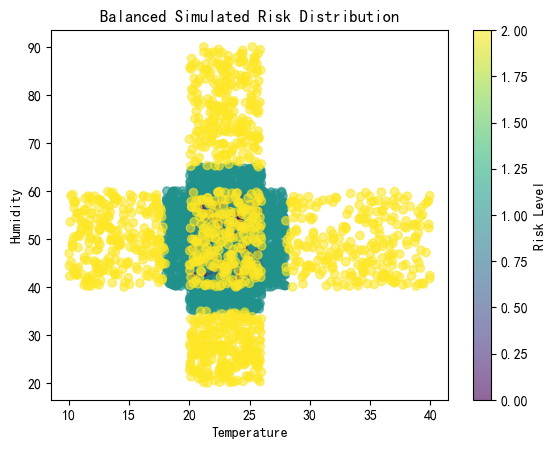

In [ ]:
# ----------------- 2. 风险评估函数 -----------------
'''
低: t:20-26 h:40-60 g:0-0.1
中: t:18-20 26-28 h:35-40 60-65 g:0.1-0.2
高: t:<18 >28 h:<35 >65 g:>0.2
'''
def evaluate(t, h, g):
    if t < 18 or t > 28 or h < 35 or h > 65 or g > 0.2:
        return 2  # 高风险
    if (18 <= t < 20 or 26 < t <= 28 or
        35 <= h < 40 or 60 < h <= 65 or
        0.1 < g <= 0.2):
        return 1  # 轻度风险
    return 0  # 安全

# 拼接risk
risk = np.array([evaluate(t, h, g) for t, h, g in zip(temp, humi, gray)])

# ----------------- 3. 构建 DataFrame -----------------
df = pd.DataFrame({
    "temp": temp,
    "humi": humi,
    "gray": gray,
    "risk": risk
})
df = df.round({
    "temp": 2,
    "humi": 2,
    "gray": 3
})

print(df['risk'].value_counts())  # 检查各等级数量

# 可视化
plt.scatter(df['temp'], df['humi'], c=df['risk'], cmap='viridis', alpha=0.6)
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.title("Balanced Simulated Risk Distribution")
plt.colorbar(label="Risk Level")
plt.show()

In [10]:
# ----------------- 4. 数据拆分 -----------------
from sklearn.model_selection import train_test_split

X = df[['temp', 'humi', 'gray']].values.astype(np.float32)
y = df['risk'].values.astype(np.float32)  # 单输出回归模型

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# ----------------- 5. 创建神经网络 -----------------
model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(3,)),  # 三个输入
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1)  # 输出风险等级（浮点）
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

d:\conda_envs\ESP32_env\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 353 (1.38 KB)

 Trainable params: 353 (1.38 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# ----------------- 6. 模型训练 -----------------
model.fit(X_train, y_train, epochs=2000, batch_size=32, validation_split=0.2, verbose=2)

Epoch 1/2000
70/70 - 1s - 10ms/step - loss: 32.6266 - mae: 3.7055 - val_loss: 0.7715 - val_mae: 0.7186
Epoch 2/2000
70/70 - 0s - 2ms/step - loss: 0.7467 - mae: 0.7000 - val_loss: 0.7093 - val_mae: 0.6891
Epoch 3/2000
70/70 - 0s - 2ms/step - loss: 0.6851 - mae: 0.6710 - val_loss: 0.6641 - val_mae: 0.6661
Epoch 4/2000
70/70 - 0s - 2ms/step - loss: 0.6469 - mae: 0.6500 - val_loss: 0.6400 - val_mae: 0.6548
Epoch 5/2000
70/70 - 0s - 2ms/step - loss: 0.6216 - mae: 0.6387 - val_loss: 0.6254 - val_mae: 0.6430
Epoch 6/2000
70/70 - 0s - 2ms/step - loss: 0.6094 - mae: 0.6319 - val_loss: 0.6119 - val_mae: 0.6373
Epoch 7/2000
70/70 - 0s - 2ms/step - loss: 0.5932 - mae: 0.6263 - val_loss: 0.6002 - val_mae: 0.6331
Epoch 8/2000
70/70 - 0s - 2ms/step - loss: 0.5890 - mae: 0.6258 - val_loss: 0.5907 - val_mae: 0.6308
Epoch 9/2000
70/70 - 0s - 2ms/step - loss: 0.5680 - mae: 0.6143 - val_loss: 0.5731 - val_mae: 0.6210
Epoch 10/2000
70/70 - 0s - 2ms/step - loss: 0.5516 - mae: 0.6061 - val_loss: 0.5622 - val

In [15]:
# ----------------- 7. 保存 TFLite FP32 模型 -----------------
import pathlib

# 假设 model 已经训练完成
# model.fit(...)

# ----------------- 1. 直接转换 Keras 模型 -----------------
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = []               # 不做任何优化
converter.target_spec.supported_types = [tf.float32]  # 使用 ESP32

tflite_model = converter.convert()

# ----------------- 2. 保存 TFLite 文件 -----------------
tflite_model_file = pathlib.Path('model.tflite')
tflite_model_file.write_bytes(tflite_model)
print("ESP32 TFLite 模型已保存为:", tflite_model_file)

# ----------------- 3. 生成 C++ 数组 -----------------
cc_file_path = pathlib.Path("model.cc")
with open(cc_file_path, "w", encoding="utf-8") as f:
    f.write('#include "model.h"\n\n')
    f.write("const unsigned char g_model[] = {\n")
    for i, b in enumerate(tflite_model):
        if i % 12 == 0:
            f.write("    ")
        f.write(f"0x{b:02x}, ")
        if (i + 1) % 12 == 0:
            f.write("\n")
    f.write("\n};\n\n")
    f.write(f"const int g_model_len = {len(tflite_model)};\n")

print(f"model.cc 已生成，长度 {len(tflite_model)} 字节")

INFO:tensorflow:Assets written to: C:\Users\lxl\AppData\Local\Temp\tmp0_7pwwny\assets


INFO:tensorflow:Assets written to: C:\Users\lxl\AppData\Local\Temp\tmp0_7pwwny\assets


Saved artifact at 'C:\Users\lxl\AppData\Local\Temp\tmp0_7pwwny'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  1604162635920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1604162637072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1604162635728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1604162634960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1604162637648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1604162635152: TensorSpec(shape=(), dtype=tf.resource, name=None)
ESP32 TFLite 模型已保存为: model.tflite
model.cc 已生成，长度 3292 字节
